# Ensemble Affinity Analysis (On-the-fly)

This notebook computes PRP and RA summaries in memory from merged benchmark files.

No summary CSVs are created and figures are shown inline only.

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [10]:
run_dir

PosixPath('/mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/data/results/affinity_benchmark/20260331_132055')

In [11]:
# Set run_id explicitly, or keep None to use latest run folder.
run_id = None

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"

if run_id is None:
    run_dirs = sorted([p for p in bench_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No benchmark runs found under {bench_root}")
    run_dir = run_dirs[-1]
else:
    run_dir = bench_root / run_id

prp_path = run_dir / "merged_prp_affinities.csv"
ra_path = run_dir / "merged_ra_affinities.csv"

# if not prp_path.exists() or not ra_path.exists():
#     raise FileNotFoundError(
#         "Merged files not found. Run scripts/run_postprocessing.py first for this run_id."
#     )

prp_df = pd.read_csv(prp_path)
ra_df = pd.read_csv(ra_path)

print("Run directory:", run_dir)
print("PRP rows:", len(prp_df), "| Models:", prp_df['Model_Slug'].nunique())
print("RA rows:", len(ra_df), "| Models:", ra_df['Model_Slug'].nunique())

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/data/results/affinity_benchmark/20260331_130412/merged_ra_affinities.csv'

In [12]:
# Quick coverage checks
display(prp_df[['Model_Slug', 'Abstract_Index']].drop_duplicates().groupby('Model_Slug').size().rename('n_abstracts').reset_index())
display(ra_df[['Model_Slug', 'Abstract_Index']].drop_duplicates().groupby('Model_Slug').size().rename('n_abstracts').reset_index())

,Model_Slug,n_abstracts
0,llama3.1-latest,1
1,ministral-3-latest,1


NameError: name 'ra_df' is not defined

## PRP Summaries (Computed On-the-fly)

In [13]:
prp_summary = (
    prp_df.groupby(['Model_Slug', 'PRP_Name'], as_index=False)['LLM_Affinity']
    .agg(mean_affinity='mean', std_affinity='std', n='count')
)
display(prp_summary.head(20))

,Model_Slug,PRP_Name,mean_affinity,std_affinity,n
0,llama3.1-latest,CROF,10.0,NaN,1
1,llama3.1-latest,DER,20.0,NaN,1
2,llama3.1-latest,IBR,0.0,NaN,1
3,llama3.1-latest,Planning,90.0,NaN,1
4,llama3.1-latest,Stability,60.0,NaN,1
5,llama3.1-latest,System Services,80.0,NaN,1
6,ministral-3-latest,CROF,10.0,NaN,1
7,ministral-3-latest,DER,10.0,NaN,1
8,ministral-3-latest,IBR,10.0,NaN,1
9,ministral-3-latest,Planning,95.0,NaN,1


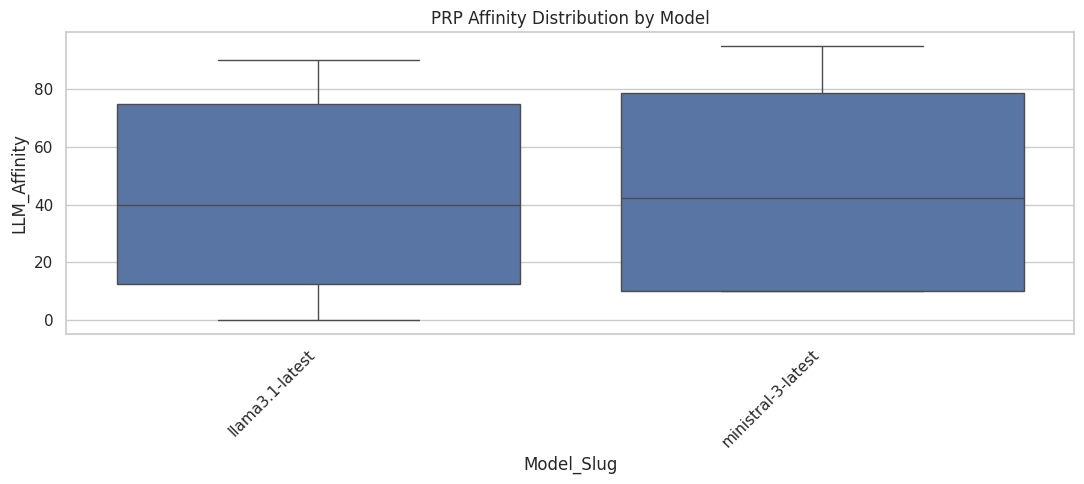

In [14]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=prp_df, x='Model_Slug', y='LLM_Affinity')
plt.title('PRP Affinity Distribution by Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

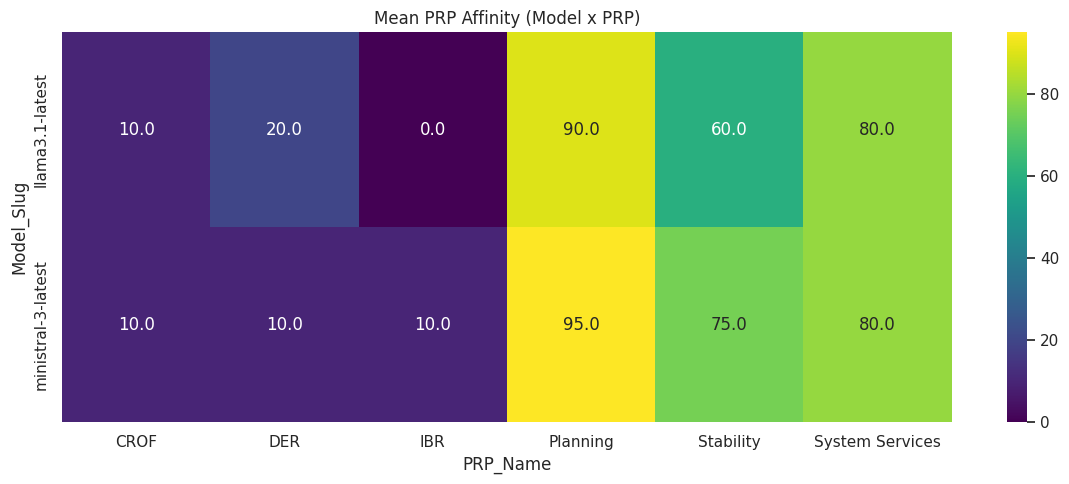

In [15]:
prp_heat = prp_summary.pivot(index='Model_Slug', columns='PRP_Name', values='mean_affinity').sort_index()
plt.figure(figsize=(12, 5))
sns.heatmap(prp_heat, annot=True, fmt='.1f', cmap='viridis')
plt.title('Mean PRP Affinity (Model x PRP)')
plt.tight_layout()
plt.show()

In [16]:
# Top-1 PRP agreement per abstract
prp_top1 = (
    prp_df.sort_values(['Model_Slug', 'Abstract_Index', 'LLM_Affinity'], ascending=[True, True, False])
    .groupby(['Model_Slug', 'Abstract_Index'], as_index=False)
    .first()[['Model_Slug', 'Abstract_Index', 'PRP_Name']]
)

prp_agreement = (
    prp_top1.groupby('Abstract_Index')['PRP_Name']
    .nunique()
    .rename('n_unique_top1_prp')
    .reset_index()
)

print('Full agreement rate (all models same top-1 PRP):', (prp_agreement['n_unique_top1_prp'] == 1).mean())
display(prp_agreement['n_unique_top1_prp'].value_counts().sort_index().rename('n_abstracts'))

Full agreement rate (all models same top-1 PRP): 1.0


n_unique_top1_prp
1    1
Name: n_abstracts, dtype: int64

## RA Summaries (Computed On-the-fly)

In [17]:
ra_summary = (
    ra_df.groupby(['Model_Slug', 'RA2025_ID'], as_index=False)['LLM_Affinity']
    .agg(mean_affinity='mean', std_affinity='std', n='count')
)
display(ra_summary.head(20))

NameError: name 'ra_df' is not defined

In [ ]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=ra_df, x='Model_Slug', y='LLM_Affinity')
plt.title('RA Affinity Distribution by Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Top-1 RA agreement per abstract
ra_top1 = (
    ra_df.sort_values(['Model_Slug', 'Abstract_Index', 'LLM_Affinity'], ascending=[True, True, False])
    .groupby(['Model_Slug', 'Abstract_Index'], as_index=False)
    .first()[['Model_Slug', 'Abstract_Index', 'RA2025_ID']]
)

ra_agreement = (
    ra_top1.groupby('Abstract_Index')['RA2025_ID']
    .nunique()
    .rename('n_unique_top1_ra')
    .reset_index()
)

print('Full agreement rate (all models same top-1 RA):', (ra_agreement['n_unique_top1_ra'] == 1).mean())
display(ra_agreement['n_unique_top1_ra'].value_counts().sort_index().rename('n_abstracts'))